### Item Item CF Model

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv('travel_data.csv')
data.head()

,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [13]:
# data cleaning
data['city'] = data['city'] + ', ' + data['country']

cf_data = data[['city', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']]

cf_data.set_index('city', inplace=True)

cf_data.head()

onehot_X = pd.get_dummies(cf_data, drop_first=True, dtype = int)
onehot_X.head()

city_df = onehot_X.T
city_df

city,"Milan, Italy","Yasawa Islands, Fiji","Whistler, Canada","Guanajuato, Mexico","Surabaya, Indonesia","Nuuk, Greenland","Windhoek, Namibia","Kingston, Jamaica","Nafplio, Greece","Tbilisi, Georgia",...,"Savusavu, Fiji","Bristol, United Kingdom","Rovaniemi, Finland","Viña del Mar, Chile","Nelson, New Zealand","Maun, Botswana","Gothenburg, Sweden","Manchester, United Kingdom","Copenhagen, Denmark","Sucre, Bolivia"
culture,5,2,3,5,4,3,3,4,4,4,...,3,4,3,3,3,3,4,4,5,4
adventure,2,4,5,3,3,4,4,3,3,3,...,4,3,4,3,4,5,3,2,2,3
nature,2,5,5,3,3,5,4,3,4,3,...,5,3,5,4,5,5,4,2,3,3
beaches,1,5,2,1,2,2,1,3,3,1,...,5,2,1,4,3,1,3,1,2,1
nightlife,4,2,3,3,3,2,3,4,3,3,...,2,4,2,4,2,2,3,4,4,2
cuisine,5,3,3,4,4,3,3,4,4,4,...,3,4,3,4,3,3,4,4,4,3
wellness,3,4,4,3,3,2,3,3,3,3,...,4,3,3,3,3,3,3,3,3,2
urban,5,1,2,4,4,2,3,3,3,3,...,2,4,2,4,3,2,4,4,5,2
seclusion,2,5,4,2,2,5,4,2,4,3,...,5,2,4,2,4,4,3,2,2,4


In [14]:
# Functions for item-item collaborative filtering

def cosine_sim(x, y):
    return ((x.T @ y) /(np.sqrt(x.T @ x) * np.sqrt(y.T @ y))).item()

def min_max(a):
    a_min = a.min()
    a_max = a.max()

    min_max = (a - a_min) / (a_max - a_min)
    return min_max


def item_collab_filter(df, targ_user, sim_score='Cosine', k=2):
    # center data and get mean of each items
    centered_df = df.sub(df.mean(axis=0), axis=1)
    items_mean = df.mean(axis=0)

    missing_items = df.loc[targ_user, :][df.loc[targ_user, :].isna()].index

    pred_rating_dict = {}

    for item in missing_items:
        scores = {}
        for comp_item in centered_df.columns:
            # nan for same items in pairwise comparison
            if item == comp_item:
                scores[comp_item] = np.nan
            else:
                # Both items have to be rated
                pair = centered_df[[item, comp_item]].dropna()

                array1 = np.asarray(pair[item]).reshape(len(pair), 1)
                array2 = np.asarray(pair[comp_item]).reshape(len(pair), 1)

                # calculate similarity scores
                if sim_score == 'Cosine':
                    scores[comp_item] = cosine_sim(array1, array2)
                elif sim_score == 'L2':
                    scores[comp_item] = -np.linalg.norm(array1 - array2, ord=2)

        # min max scaling
        scores = pd.Series(scores)
        scores = min_max(scores)

        # find k most similar items
        k_similar_items = scores.dropna().nlargest(k)

        # fill in missing ratings with item means
        user_ratings = df.loc[targ_user, k_similar_items.index]
        user_ratings = user_ratings.fillna(items_mean)

        # predict rating
        pred_rating = sum(user_ratings * k_similar_items)/sum(k_similar_items)
        pred_rating_dict[item] = pred_rating

    return pred_rating_dict

In [15]:
# Set up functions for removing random ratings and evaluating predictions

def remove_category(df, category, remove_chance=0.2, seed=42):
    np.random.seed(seed)
    
    # Initlaize dataframe and true values
    df_rem = df.copy()
    true_values = {}
    
    for col in df.columns:
        if np.random.random() < remove_chance:  # randomly decide to remove rating
            true_values[col] = df.loc[category, col]  # store true value
            df_rem.loc[category, col] = np.nan
    
    return df_rem, true_values


def evaluate_cf(pred_rating_dict, true_values):
    preds = []
    actuals = []
    
    for item, pred_val in pred_rating_dict.items():
        if item in true_values:
            preds.append(pred_val)
            actuals.append(true_values[item])
    
    preds = np.array(preds)
    actuals = np.array(actuals)
    
    mae = np.mean(np.abs(preds - actuals))
    rmse = np.sqrt(np.mean((preds - actuals) ** 2))
    
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    return mae, rmse

In [22]:
## Testing model
category = 'culture'

df_rem, true_values = remove_category(city_df, category, 0.2, 42)

# K=2
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=2)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=2)

print("\nK=2")
print("\nCosine Similarity:")
mae_k2_cos_cult, rmse_k2_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k2_l2_cult, rmse_k2_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)

# K=5
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=5)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=5)

print("\nK=5")
print("\nCosine Similarity:")
mae_k5_cos_cult, rmse_k5_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k5_l2_cult, rmse_k5_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)

# K=7
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=7)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=7)

print("\nK=7")
print("\nCosine Similarity:")
mae_k7_cos_cult, rmse_k7_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k7_l2_cult, rmse_k7_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)

# K=10
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=10)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=10)

print("\nK=10")
print("\nCosine Similarity:")
mae_k10_cos_cult, rmse_k10_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k10_l2_cult, rmse_k10_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)

# K=15
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=15)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=15)

print("\nK=15")
print("\nCosine Similarity:")
mae_k15_cos_cult, rmse_k15_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k15_l2_cult, rmse_k15_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)

# K=20
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=20)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=20)

print("\nK=20")
print("\nCosine Similarity:")
mae_k20_cos_cult, rmse_k20_cos_cult = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k20_l2_cult, rmse_k20_l2_cult = evaluate_cf(pred_rating_dict_L2, true_values)


K=2

Cosine Similarity:
MAE:  0.6595
RMSE: 0.8686

L2 Similarity:
MAE:  0.6620
RMSE: 0.8604

K=5

Cosine Similarity:
MAE:  0.5785
RMSE: 0.7413

L2 Similarity:
MAE:  0.5951
RMSE: 0.7782

K=7

Cosine Similarity:
MAE:  0.5656
RMSE: 0.7211

L2 Similarity:
MAE:  0.5788
RMSE: 0.7634

K=10

Cosine Similarity:
MAE:  0.5430
RMSE: 0.7070

L2 Similarity:
MAE:  0.5490
RMSE: 0.7244

K=15

Cosine Similarity:
MAE:  0.5466
RMSE: 0.7152

L2 Similarity:
MAE:  0.5415
RMSE: 0.7053

K=20

Cosine Similarity:
MAE:  0.5273
RMSE: 0.6974

L2 Similarity:
MAE:  0.5228
RMSE: 0.6844


In [17]:
## Testing model
category = 'beaches'

df_rem, true_values = remove_category(city_df, category, 0.2, 42)

# K=2
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=2)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=2)

print("\nK=2")
print("\nCosine Similarity:")
mae_k2_cos_beach, rmse_k2_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k2_l2_beach, rmse_k2_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)

# K=5
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=5)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=5)

print("\nK=5")
print("\nCosine Similarity:")
mae_k5_cos_beach, rmse_k5_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k5_l2_beach, rmse_k5_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)

# K=7
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=7)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=7)

print("\nK=7")
print("\nCosine Similarity:")
mae_k7_cos_beach, rmse_k7_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k7_l2_beach, rmse_k7_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)

# K=10
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=10)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=10)

print("\nK=10")
print("\nCosine Similarity:")
mae_k10_cos_beach, rmse_k10_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k10_l2_beach, rmse_k10_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)

# K=15
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=15)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=15)

print("\nK=15")
print("\nCosine Similarity:")
mae_k15_cos_beach, rmse_k15_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k15_l2_beach, rmse_k15_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)

# K=20
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=20)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=20)

print("\nK=20")
print("\nCosine Similarity:")
mae_k20_cos_beach, rmse_k20_cos_beach = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k20_l2_beach, rmse_k20_l2_beach = evaluate_cf(pred_rating_dict_L2, true_values)


K=2

Cosine Similarity:
MAE:  1.1981
RMSE: 1.4114

L2 Similarity:
MAE:  1.2332
RMSE: 1.4427

K=5

Cosine Similarity:
MAE:  1.1530
RMSE: 1.3549

L2 Similarity:
MAE:  1.1808
RMSE: 1.3861

K=7

Cosine Similarity:
MAE:  1.1365
RMSE: 1.3357

L2 Similarity:
MAE:  1.1740
RMSE: 1.3810

K=10

Cosine Similarity:
MAE:  1.1459
RMSE: 1.3420

L2 Similarity:
MAE:  1.1559
RMSE: 1.3646

K=15

Cosine Similarity:
MAE:  1.1309
RMSE: 1.3257

L2 Similarity:
MAE:  1.1365
RMSE: 1.3375

K=20

Cosine Similarity:
MAE:  1.1374
RMSE: 1.3215

L2 Similarity:
MAE:  1.1180
RMSE: 1.3200


In [18]:
## Testing model
category = 'urban'

df_rem, true_values = remove_category(city_df, category, 0.2, 42)

# K=2
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=2)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=2)

print("\nK=2")
print("\nCosine Similarity:")
mae_k2_cos_urb, rmse_k2_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k2_l2_urb, rmse_k2_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)

# K=5
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=5)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=5)

print("\nK=5")
print("\nCosine Similarity:")
mae_k5_cos_urb, rmse_k5_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k5_l2_urb, rmse_k5_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)

# K=7
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=7)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=7)

print("\nK=7")
print("\nCosine Similarity:")
mae_k7_cos_urb, rmse_k7_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k7_l2_urb, rmse_k7_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)

# K=10
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=10)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=10)

print("\nK=10")
print("\nCosine Similarity:")
mae_k10_cos_urb, rmse_k10_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k10_l2_urb, rmse_k10_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)

# K=15
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=15)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=15)

print("\nK=15")
print("\nCosine Similarity:")
mae_k15_cos_urb, rmse_k15_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k15_l2_urb, rmse_k15_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)

# K=20
pred_rating_dict_cos = item_collab_filter(df_rem, category, sim_score='Cosine', k=20)
pred_rating_dict_L2 = item_collab_filter(df_rem, category, sim_score='L2', k=20)

print("\nK=20")
print("\nCosine Similarity:")
mae_k20_cos_urb, rmse_k20_cos_urb = evaluate_cf(pred_rating_dict_cos, true_values)

print("\nL2 Similarity:")
mae_k20_l2_urb, rmse_k20_l2_urb = evaluate_cf(pred_rating_dict_L2, true_values)


K=2

Cosine Similarity:
MAE:  0.6228
RMSE: 0.8555

L2 Similarity:
MAE:  0.6894
RMSE: 0.8935

K=5

Cosine Similarity:
MAE:  0.5724
RMSE: 0.7333

L2 Similarity:
MAE:  0.6561
RMSE: 0.8100

K=7

Cosine Similarity:
MAE:  0.5764
RMSE: 0.7169

L2 Similarity:
MAE:  0.6424
RMSE: 0.8039

K=10

Cosine Similarity:
MAE:  0.5553
RMSE: 0.7057

L2 Similarity:
MAE:  0.6078
RMSE: 0.7680

K=15

Cosine Similarity:
MAE:  0.5316
RMSE: 0.6722

L2 Similarity:
MAE:  0.5651
RMSE: 0.7111

K=20

Cosine Similarity:
MAE:  0.5271
RMSE: 0.6598

L2 Similarity:
MAE:  0.5528
RMSE: 0.7012


In [32]:
# put mse and rmse results into a dataframe
categories = ['cult', 'beach', 'urb']
k_values = [2, 5, 7, 10, 15, 20]  
metrics = ['mae', 'rmse']

rows = []
for k in k_values:
    for cat in categories:
        for sim in ['cos', 'l2']:
            mae_var = f'mae_k{k}_{sim}_{cat}'
            rmse_var = f'rmse_k{k}_{sim}_{cat}'
            rows.append({
                'k': k,
                'category': cat,
                'similarity': sim,
                'mae': eval(mae_var),
                'rmse': eval(rmse_var)
            })

results_df = pd.DataFrame(rows)
print(results_df)

     k category similarity       mae      rmse
0    2     cult        cos  0.659520  0.868550
1    2     cult         l2  0.661972  0.860373
2    2    beach        cos  1.198120  1.411371
3    2    beach         l2  1.233153  1.442709
4    2      urb        cos  0.622772  0.855468
5    2      urb         l2  0.689370  0.893512
6    5     cult        cos  0.578464  0.741264
7    5     cult         l2  0.595126  0.778176
8    5    beach        cos  1.152982  1.354927
9    5    beach         l2  1.180770  1.386146
10   5      urb        cos  0.572392  0.733295
11   5      urb         l2  0.656129  0.809997
12   7     cult        cos  0.565570  0.721094
13   7     cult         l2  0.578809  0.763380
14   7    beach        cos  1.136496  1.335703
15   7    beach         l2  1.173973  1.381030
16   7      urb        cos  0.576405  0.716880
17   7      urb         l2  0.642363  0.803935
18  10     cult        cos  0.543033  0.707004
19  10     cult         l2  0.548988  0.724392
20  10    bea

In [33]:
k_comp_results_df = results_df.groupby(['k', 'similarity'])[['mae', 'rmse']].mean().reset_index()

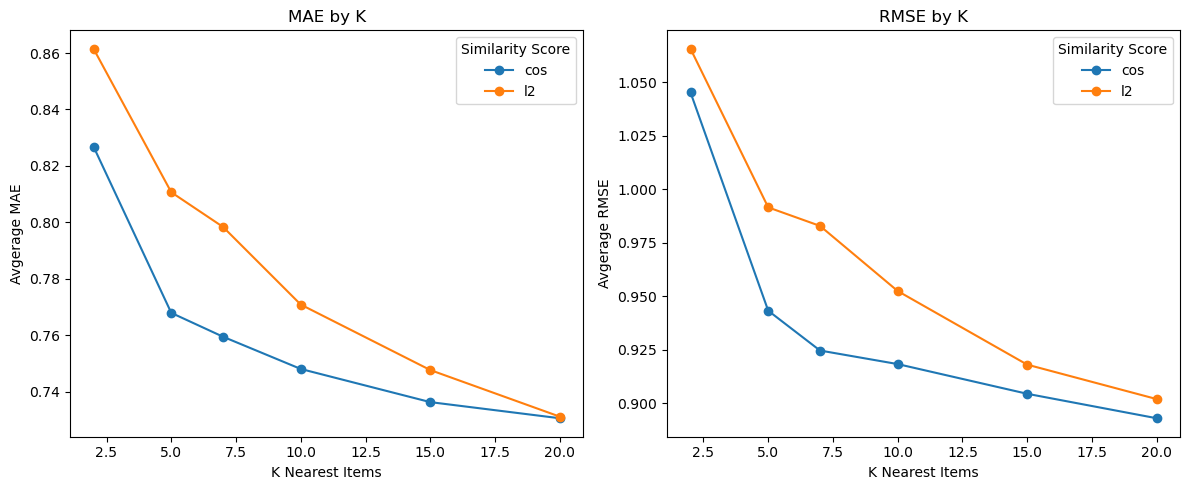

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['mae', 'rmse']):
    for sim in ['cos', 'l2']:
        subset = k_comp_results_df[k_comp_results_df['similarity'] == sim]
        ax.plot(subset['k'], subset[metric], marker='o', label=sim)
    ax.set_title(f'{metric.upper()} by K')
    ax.set_xlabel('K Nearest Items')
    ax.set_ylabel(f'Avgerage {metric.upper()}')
    ax.legend(title='Similarity Score')

plt.tight_layout()
plt.show()

In [40]:
sim_score_comp_df = results_df.groupby(['similarity'])[['mae', 'rmse']].mean().reset_index()
sim_score_comp_df

,similarity,mae,rmse
0,cos,0.761545,0.938057
1,l2,0.786722,0.968657


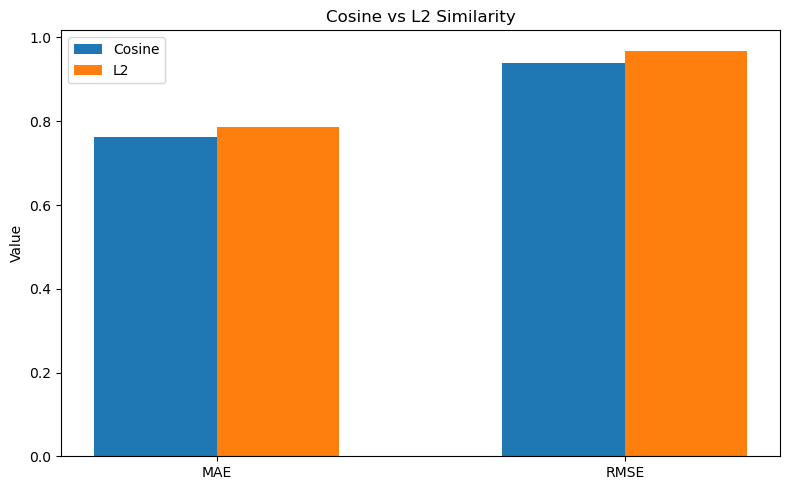

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['mae', 'rmse']
x = np.arange(len(metrics))
width = 0.3

cos_vals = [0.761545, 0.938057]
l2_vals = [0.786722, 0.968657]

ax.bar(x - width/2, cos_vals, width, label='Cosine')
ax.bar(x + width/2, l2_vals, width, label='L2')

ax.set_xticks(x)
ax.set_xticklabels(['MAE', 'RMSE'])
ax.set_ylabel('Value')
ax.set_title('Cosine vs L2 Similarity')
ax.legend()

plt.tight_layout()
plt.show()

